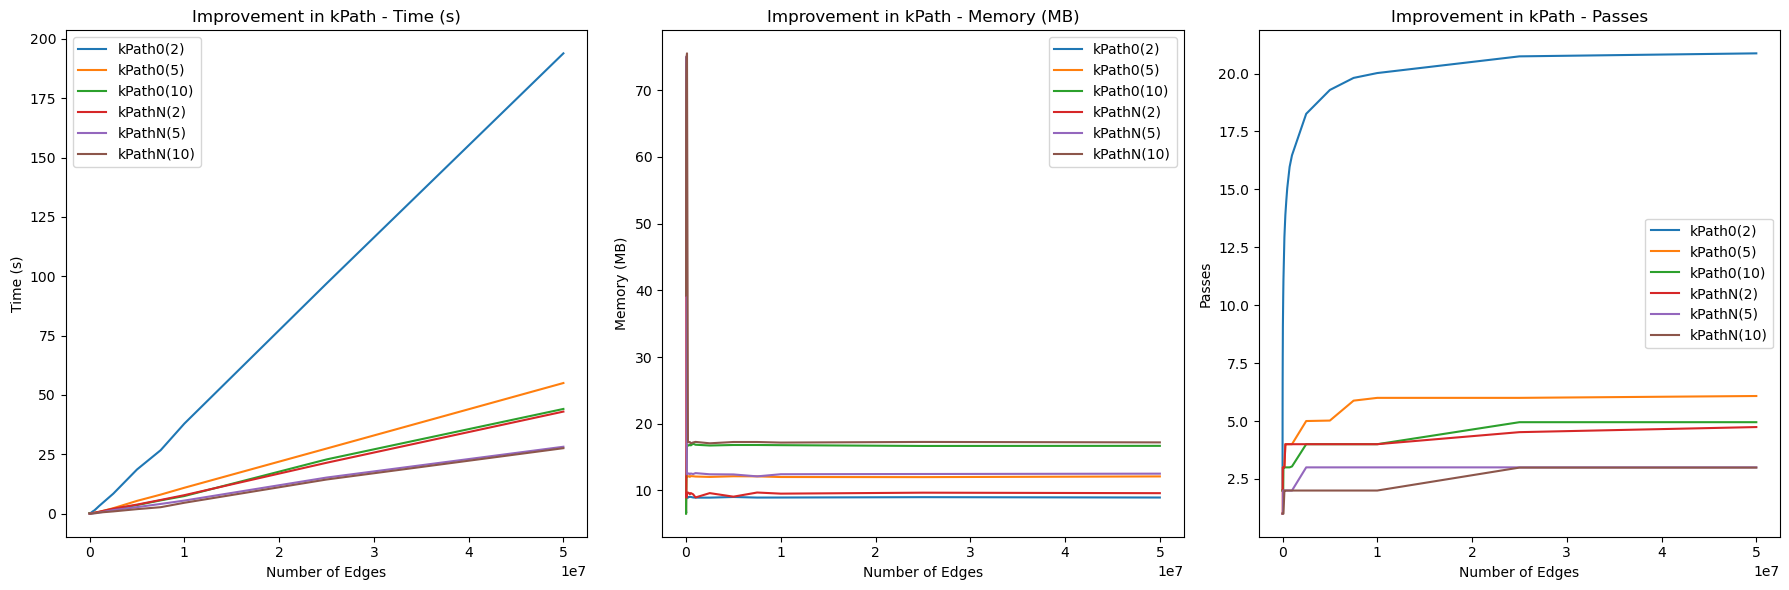

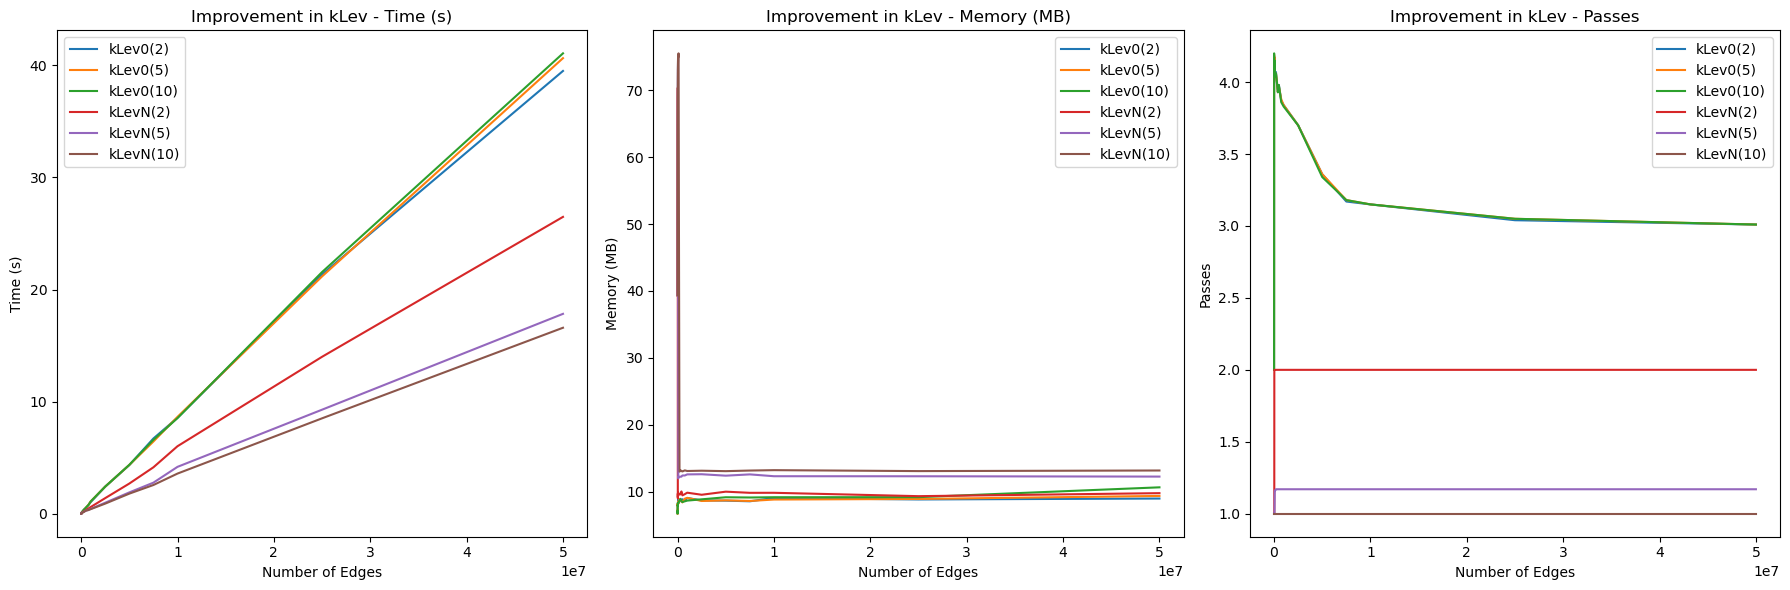

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# Define the folder path
data_folder = '../../results/random/VARM/'

variants = ["0", "N"]
k_values = [2, 5, 10]

def plot(graph_type, algorithm):
    fig, axs = plt.subplots(1, 3, figsize=(18, 6))  # Adjust figsize to control the overall size

    columns = ['Time (s)', 'Memory (MB)', 'Passes']
    # Convert memory values from KB to MB
    memory_column = 'Memory (KB)'
    converted_memory_column = 'Memory (MB)'
    for variant in variants:
        for k in k_values:
            folder_path = os.path.join(data_folder, graph_type)
            matching_folders = [f for f in os.listdir(folder_path) if f.startswith(algorithm)]
            
            if not matching_folders:
                print(f"No folder found starting with {algorithm}{variant} in {folder_path}")
                continue

            selected_folder = matching_folders[0]
            file_path = os.path.join(folder_path, selected_folder, f'{algorithm}{variant}({k}).csv')
            
            if os.path.exists(file_path):
                data = pd.read_csv(file_path)
                data[converted_memory_column] = data[memory_column] / 1024  # Convert KB to MB
            else:
                print(f"File not found: {file_path}")
                continue
            
            for j, column in enumerate(columns):
                axs[j].plot(data['M'], data[column], label=f'{algorithm}{variant}({k})')
                axs[j].set_title(f'Improvement in {algorithm} - {column}')
                axs[j].set_xlabel('Number of Edges')
                axs[j].set_ylabel(column)
                axs[j].legend()

    plt.tight_layout()
    plt.show()



# Example usage
plot("UNIFORM", "kPath")
plot("UNIFORM", "kLev")